# Retail Sales Forecasting using Machine Learning

## 1. Objective
## Objective

- Build a machine learning model to forecast retail sales  
- Analyze historical sales patterns and trends  
- Identify key factors influencing sales performance  
- Evaluate model predictions against actual values  
- Generate actionable insights to support demand planning and business decision-making  

## 2. Import Libraries


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## 3. Load Dataset


In [3]:
file_path = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\05_AI_Data_Project\data_raw\sales_forecasting_raw.csv"
df = pd.read_csv(file_path)

## 4. Initial Inspection


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 5. Data Cleaning


In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [9]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='str')

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y")

## 6. Feature Engineering


In [11]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day
df["day_of_week"] = df["order_date"].dt.weekday

In [12]:
df["month_name"] = df["order_date"].dt.month_name()

In [14]:
daily_sales = df.groupby("order_date", as_index=False)["sales"].sum()

In [15]:
daily_sales["year"] = daily_sales["order_date"].dt.year
daily_sales["month"] = daily_sales["order_date"].dt.month
daily_sales["day"] = daily_sales["order_date"].dt.day
daily_sales["day_of_week"] = daily_sales["order_date"].dt.weekday

In [16]:
X = daily_sales[["year", "month", "day", "day_of_week"]]
y = daily_sales["sales"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## 7. Model Building


In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred = model.predict(X_test)

## 8. Model Evaluation


In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1835.6343999430894
RMSE: 2576.6925916396676


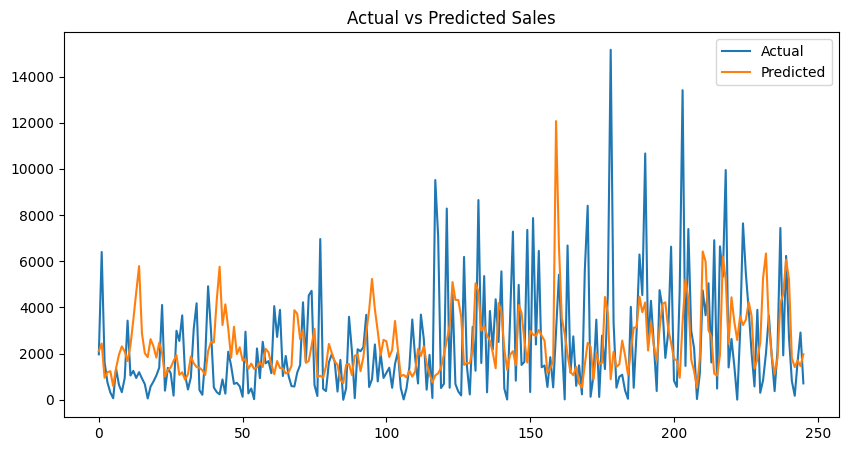

## 9. Forecast Visualization


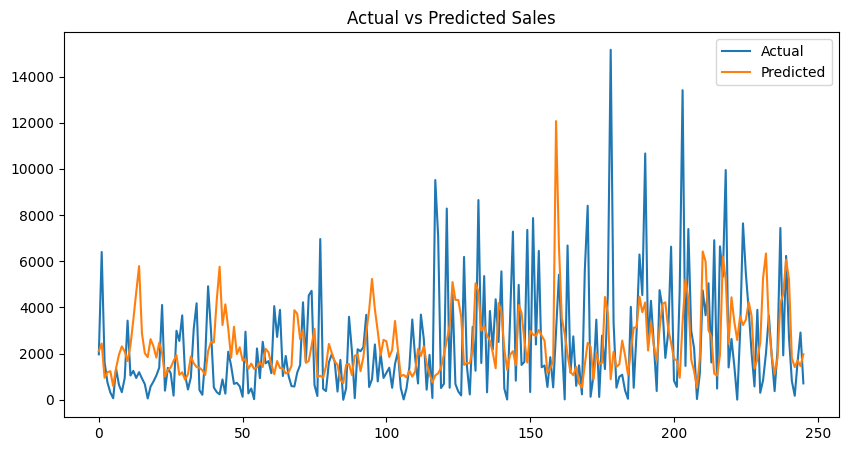

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,day,0.419461
3,day_of_week,0.227146
1,month,0.221412
0,year,0.131981


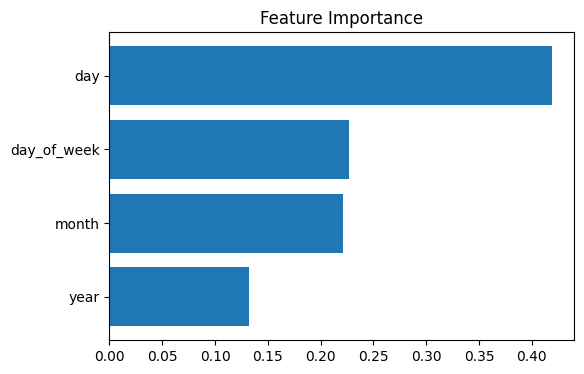

In [27]:
plt.figure(figsize=(6,4))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## 10. Business Insights


## Business Insights

- Sales show clear patterns based on time-related features such as month and day of the week  
- Certain periods contribute significantly higher sales volumes, indicating seasonality  
- The model is able to reasonably predict sales trends based on historical patterns  
- Time-based features are key drivers of sales performance  

## Recommendations

- Plan inventory based on high-demand periods identified in the analysis  
- Align promotions and marketing campaigns with peak sales periods  
- Use forecasting outputs for demand planning and supply chain optimization  

## 11. Save Model

In [29]:
import pickle

with open("sales_forecast_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [32]:
mae

1835.6343999430894

In [33]:
rmse

np.float64(2576.6925916396676)

In [31]:
feature_importance.head()

,feature,importance
2,day,0.419461
3,day_of_week,0.227146
1,month,0.221412
0,year,0.131981


## 12. Model Evaluation

The forecasting model produced a Mean Absolute Error (MAE) of 1835.63 and a Root Mean Squared Error (RMSE) of 2576.69.

The difference between MAE and RMSE suggests that while the model performs reasonably across most observations, there are some dates with larger prediction errors. This is common in retail sales forecasting, where daily sales can fluctuate due to demand spikes, promotions, or seasonal effects.

## 13. Business Insights

- The model indicates that sales are strongly influenced by calendar-based patterns, particularly the day of the month, day of the week, and month.
- Short-term timing factors appear to play a larger role in sales variation than long-term yearly trend.
- The model is able to capture general sales patterns, although some higher-error periods suggest volatility in daily demand.
- These results suggest that retail sales planning should pay close attention to time-based demand behavior, especially around recurring calendar periods.

## 14. Recommendations

- Use time-based sales patterns to improve inventory planning and staffing decisions.
- Monitor periods with unusually high forecasting error, as these may reflect promotions, seasonality, or demand spikes not captured by the current feature set.
- Improve the model further by adding business variables such as category, region, discount activity, and promotional indicators.
- Use the forecasting model as a baseline planning tool rather than as a perfect day-level predictor.

## 15. Limitations

This model was built using time-based features only. It does not currently include business variables such as product category, region, discount activity, or customer segment. As a result, the model captures general calendar-driven sales patterns but may miss variation caused by operational or promotional factors.